# 📘 Capítulo 2 – Modelos Estatísticos Clássicos

**Autor:** Rodrigo Santana Ferreira  
**Disciplina:** Séries Temporais  

---
Este notebook contém os scripts Python apresentados no Capítulo 2, organizados por seção conforme o material da aula.

## Instalação de Dependências

In [1]:
# Instalação das bibliotecas necessárias
!pip install pandas matplotlib statsmodels pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.1 MB/s eta 0:00:00


## Passo 1 – Preparação do Ambiente e Carregamento de Dados
Carregamento da série AirPassengers e visualização inicial (seção HANDS ON).

In [2]:
# Importe as bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [3]:
# Utilizando o dataset Airpassengers
from statsmodels.datasets import get_rdataset
air = get_rdataset("AirPassengers").data
air.head(50)

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
5,1949.416667,135
6,1949.500000,148
7,1949.583333,148
8,1949.666667,136
9,1949.750000,119


In [5]:
# Define o índice do DataFrame 'air' como um intervalo de datas mensais, começando em janeiro de 1949 e com o mesmo número de períodos que o comprimento de 'air'.
air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')
air.head(50)

/tmp/ipykernel_795/176911208.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  air.index = pd.date_range(start='1949-01', periods=len(air), freq='M')


,time,value
1949-01-31,1949.000000,112
1949-02-28,1949.083333,118
1949-03-31,1949.166667,132
1949-04-30,1949.250000,129
1949-05-31,1949.333333,121
1949-06-30,1949.416667,135
1949-07-31,1949.500000,148
1949-08-31,1949.583333,148
1949-09-30,1949.666667,136
1949-10-31,1949.750000,119


In [6]:
# Extrai a coluna 'value' do DataFrame 'air', converte seus valores para o tipo float e armazena-os na variável 'series'.
series = air['value'].astype(float)

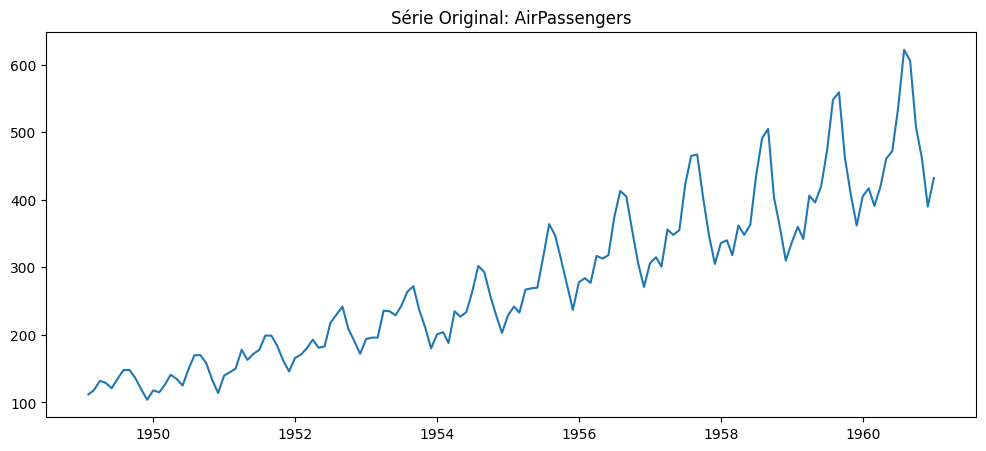

In [7]:
# plota série temporal
plt.figure(figsize=(12, 5))
plt.plot(series)
plt.title('Série Original: AirPassengers')
plt.show()

**Conhecendo a biblioteca Statsmodel**

In [8]:
# Importa a biblioteca matplotlib.pyplot para criar visualizações e gráficos.
import matplotlib.pyplot as plt
# Importa a função seasonal_decompose do módulo tsa.seasonal do statsmodels para decompor séries temporais em seus componentes.
from statsmodels.tsa.seasonal import seasonal_decompose
# Importa a classe ARIMA do módulo tsa.arima.model do statsmodels para construir e ajustar modelos ARIMA.
from statsmodels.tsa.arima.model import ARIMA
# Importa as funções plot_acf e plot_pacf do módulo graphics.tsaplots do statsmodels para plotar as funções de autocorrelação.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Importa a biblioteca numpy para realizar operações numéricas, como logaritmo.
import numpy as np

In [9]:
# --- Exemplo 1: Decomposição de Série Temporal com seasonal_decompose ---

# Realiza a decomposição de uma série temporal em seus componentes: tendência, sazonalidade e resíduos.
# 'series' é a série temporal original (variável já carregada no notebook).
# 'model='additive'' indica que os componentes são somados (valor = tendência + sazonalidade + resíduo).
# 'period=12' especifica que o padrão sazonal se repete a cada 12 pontos (comum para dados mensais).
decomposition = seasonal_decompose(series, model='additive', period=12)

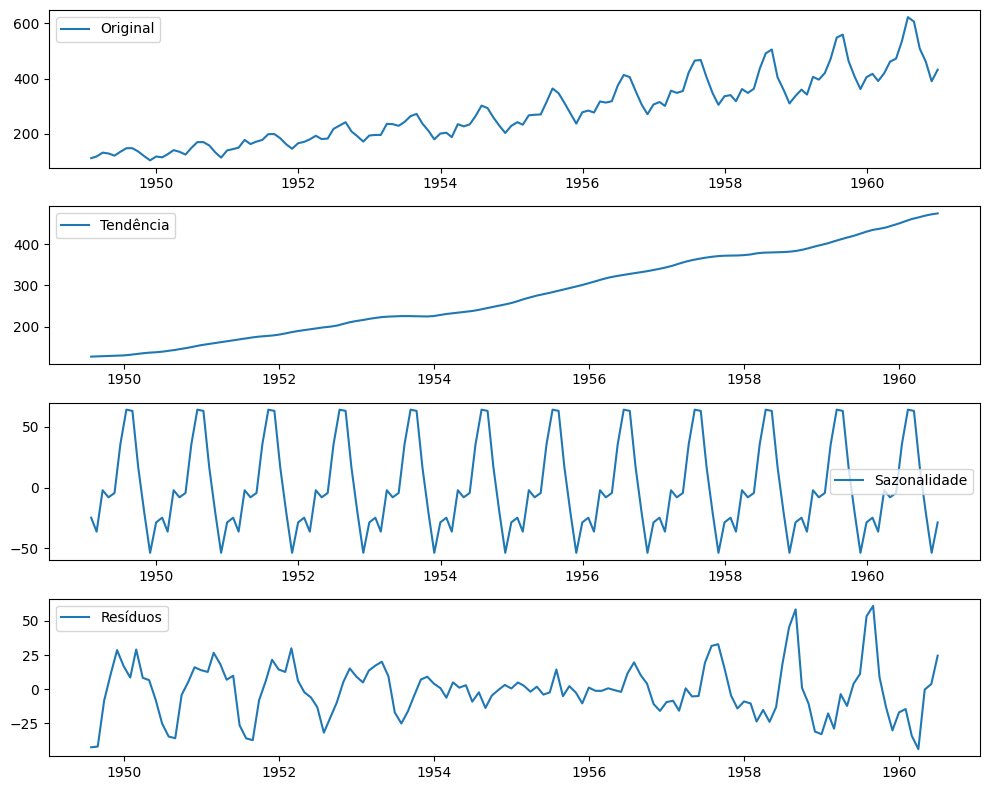

In [10]:
# Cria uma nova figura para os gráficos com um tamanho definido.
plt.figure(figsize=(10, 8))

# Cria um subplot para exibir a série original.
plt.subplot(411) # Configura 4 linhas, 1 coluna, e seleciona a primeira posição.
# Plota a série temporal original.
plt.plot(series, label='Original')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente de tendência.
plt.subplot(412) # Seleciona a segunda posição.
# Plota o componente de tendência extraído da decomposição.
plt.plot(decomposition.trend, label='Tendência')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente sazonal.
plt.subplot(413) # Seleciona a terceira posição.
# Plota o componente sazonal extraído da decomposição.
plt.plot(decomposition.seasonal, label='Sazonalidade')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Cria um subplot para exibir o componente de resíduos.
plt.subplot(414) # Seleciona a quarta posição.
# Plota os resíduos (erro) da decomposição, que idealmente devem ser ruído branco.
plt.plot(decomposition.resid, label='Resíduos')
# Adiciona uma legenda ao gráfico.
plt.legend(loc='best')

# Ajusta automaticamente os parâmetros do subplot para que os elementos caibam na figura sem sobreposição.
plt.tight_layout()
# Exibe os gráficos de decomposição.
plt.show()

In [11]:
# Importa a função adfuller do módulo statsmodels.tsa.stattools para realizar o Teste de Dickey-Fuller Aumentado.
from statsmodels.tsa.stattools import adfuller

In [12]:
# Realiza o Teste de Dickey-Fuller Aumentado (ADF) na série temporal 'series'.
# O teste ADF ajuda a determinar se a série é estacionária.
adf_test_result = adfuller(series)

In [13]:
# Extrai a estatística ADF do resultado do teste.
# Valores mais negativos da estatística ADF indicam maior probabilidade de estacionariedade.
print(f'Estatística ADF: {adf_test_result[0]:.4f}')

Estatística ADF: 0.8154


In [14]:
# Interpreta o resultado do teste ADF com base no p-value.
# Se o p-value for maior que 0.05, geralmente consideramos a série como não estacionária.
# Se for menor ou igual a 0.05, há evidências para considerar a série estacionária.
if adf_test_result[1] > 0.05:
    print('\nA série provavelmente NÃO é estacionária (p-valor > 0.05).')
else:
    print('\nA série provavelmente É estacionária (p-valor <= 0.05).')


A série provavelmente NÃO é estacionária (p-valor > 0.05).


In [15]:
# Extrai o p-value do resultado do teste.
# Um p-value baixo (ex: < 0.05) sugere que a série é estacionária (rejeita-se a hipótese nula de não estacionariedade).
print(f'P-valor: {adf_test_result[1]:.4f}')

P-valor: 0.9919


## Passo 2 – Verificação de Estacionariedade (Visual + Teste ADF)
Aplicação de log + diferenciação para tornar a série estacionária.

In [16]:
# Teste ADF
adf_result = adfuller(series)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')  # p > 0.05 → não estacionária

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


In [17]:
# Imprime os dados do dataset series
series.head()

,value
1949-01-31,112.0
1949-02-28,118.0
1949-03-31,132.0
1949-04-30,129.0
1949-05-31,121.0


<Axes: >

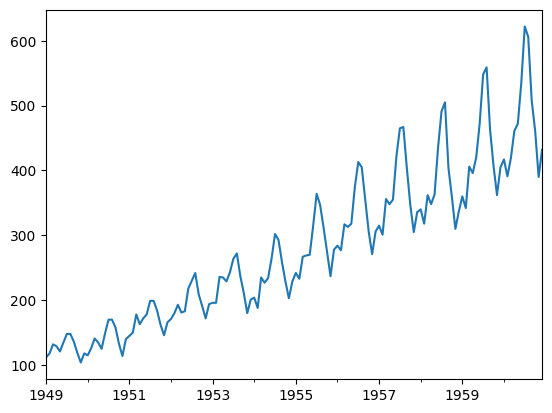

In [18]:
# verifica a visualização básica da séries
series.plot()

In [19]:
# Aplica log nos dados.
# Aplica a função logaritmo natural (np.log, que vem da biblioteca NumPy) a cada valor da série temporal chamada series.
# Essa transformação logarítmica é comum em análise de séries temporais para estabilizar a variância ou para linearizar tendências exponenciais,
# tornando a série mais adequada para modelagem.
log_series = np.log(series)

In [20]:
log_series.head(20)

,value
1949-01-31,4.718499
1949-02-28,4.770685
1949-03-31,4.882802
1949-04-30,4.859812
1949-05-31,4.795791
1949-06-30,4.905275
1949-07-31,4.997212
1949-08-31,4.997212
1949-09-30,4.912655
1949-10-31,4.779123


<Axes: >

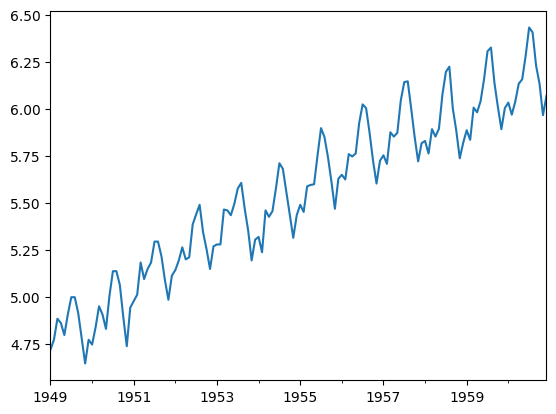

In [21]:
# plota série básica com matplotlib e pandas
log_series.plot()

In [22]:
# remove dados nulos
diff1 = log_series.diff().dropna()

<Axes: >

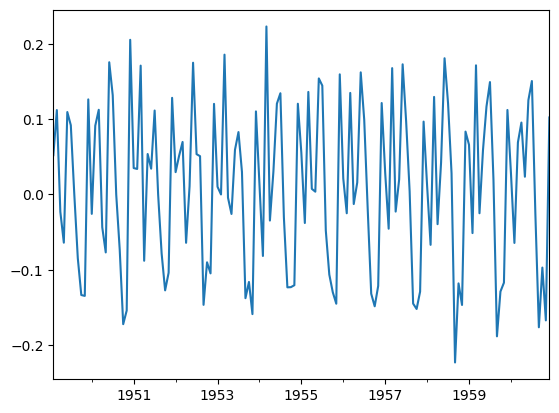

In [23]:
# plota série básica com matplotlib e pandas
diff1.plot()

In [24]:
# Remove sazonalidade
# Realiza a diferenciação sazonal.
# Pega a série diff1 (que já foi diferenciada uma vez para remover a tendência), e aplica uma nova diferenciação com um atraso de 12 períodos
 #(.diff(12)). Isso é feito para remover a sazonalidade que se repete a cada 12 pontos de dados, o que é comum em dados mensais.
diff_seasonal = diff1.diff(12).dropna()  # D=1, s=12

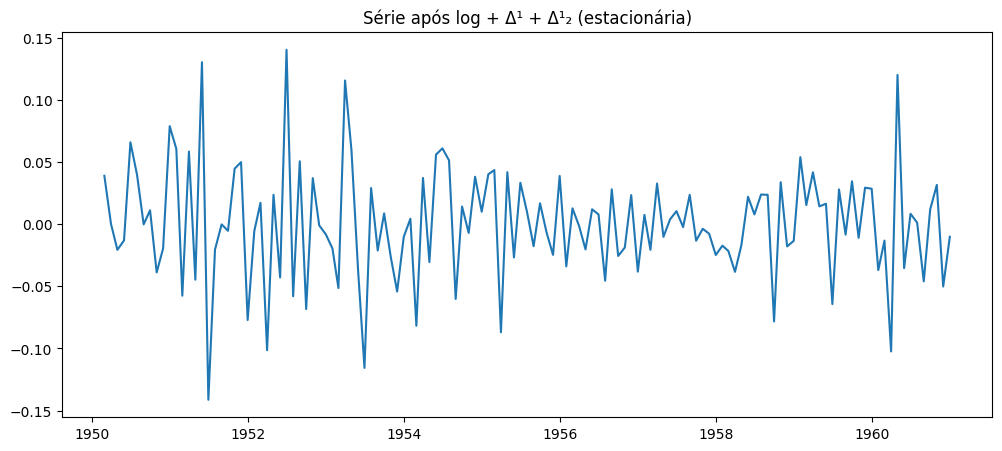

In [25]:
# Plote a série transformada
plt.figure(figsize=(12, 5))
plt.plot(diff_seasonal)
plt.title('Série após log + Δ¹ + Δ¹₂ (estacionária)')
plt.show()

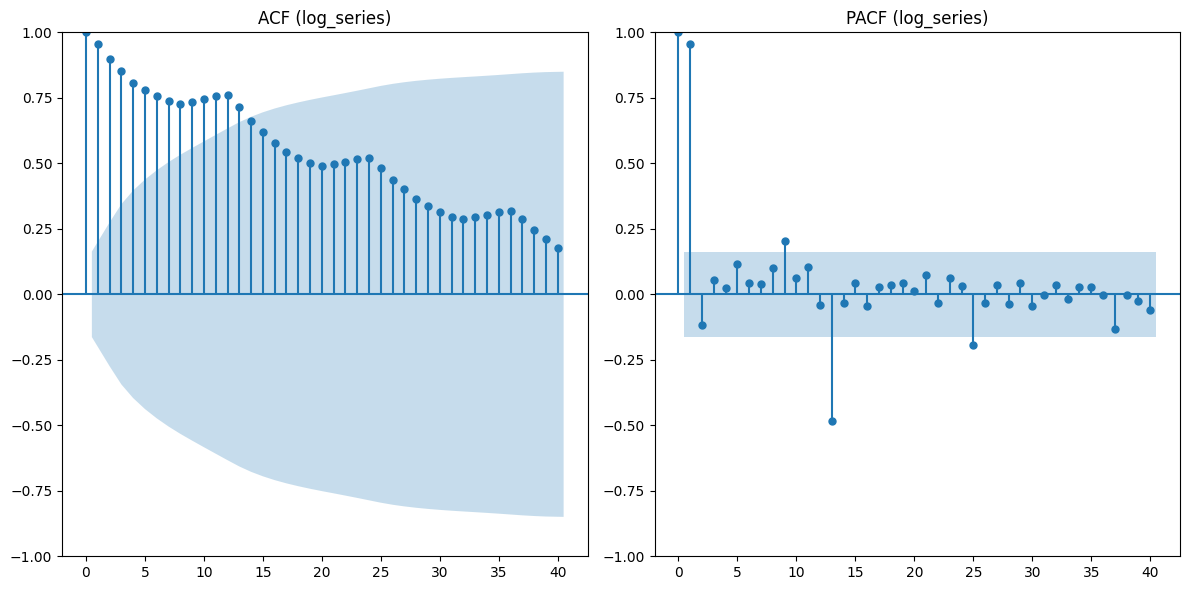

In [26]:
# Cria uma nova figura para os gráficos de ACF e PACF com um tamanho definido.
plt.figure(figsize=(12, 6))

# Cria um subplot para a Função de Autocorrelação (ACF).
plt.subplot(121) # Configura 1 linha, 2 colunas, e seleciona a primeira posição.
# Plota a ACF da 'log_series' (série com transformação logarítmica, variável já carregada no notebook).
# 'lags=40' define o número máximo de defasagens a serem exibidas.
# 'ax=plt.gca()' usa o eixo atual do subplot.

plot_acf(log_series.dropna(), lags=40, ax=plt.gca(), title='ACF (log_series)')

# Cria um subplot para a Função de Autocorrelação Parcial (PACF).
plt.subplot(122) # Seleciona a segunda posição.
# Plota a PACF da 'log_series'.
plot_pacf(log_series.dropna(), lags=40, ax=plt.gca(), title='PACF (log_series)', method='ywm')

# Ajusta automaticamente os parâmetros do subplot para evitar sobreposição.
plt.tight_layout()
# Exibe os gráficos de ACF e PACF.
plt.show()

## Passo 3 – Utilizando o modelo ARMA para previsão de séries temporais

In [27]:
# --- Exemplo 3: Ajuste e Previsão com Modelo ARMA Básico ---

# Define a ordem do modelo ARMA (p, q). Para usar a classe ARIMA para ARMA, o parâmetro 'd' é definido como 0.
# p: ordem da parte autorregressiva (AR).
# d: ordem da diferenciação (0 para ARMA).
# q: ordem da parte de média móvel (MA).
arma_order = (1, 0, 1) # Exemplo de ARMA(1,1)

# Instancia o modelo ARMA (usando a classe ARIMA com d=0) com a série 'log_series' e a ordem definida.
# A 'log_series' é frequentemente usada para estabilizar a variância antes de aplicar modelos como ARMA/ARIMA.
model_arma = ARIMA(log_series, order=arma_order)
# Ajusta o modelo ARMA aos dados, estimando os coeficientes dos parâmetros.
results_arma = model_arma.fit()

# Imprime um cabeçalho para o resumo do modelo.
print("--- Resumo do Modelo ARMA ---")
# Imprime o resumo completo do modelo ajustado, que inclui estatísticas como AIC, BIC, coeficientes, p-valores, etc.
print(results_arma.summary())

# Realiza uma previsão de 12 passos à frente usando o modelo ARMA ajustado.
# 'steps=12' indica o número de períodos futuros para os quais a previsão será gerada.
forecast_arma = results_arma.forecast(steps=12)
# Imprime um cabeçalho para as previsões.
print("\n--- Previsão ARMA (12 passos) ---")
# Exibe os valores da previsão.
print(forecast_arma)

--- Resumo do Modelo ARMA ---
                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 121.704
Date:                Wed, 17 Jun 2026   AIC                           -235.408
Time:                        21:03:56   BIC                           -223.529
Sample:                    01-31-1949   HQIC                          -230.581
                         - 12-31-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5076      0.230     23.977      0.000       5.057       5.958
ar.L1          0.9629      0.024     40.968      0.000       0.917       1.009
ma.L1          0.2968 

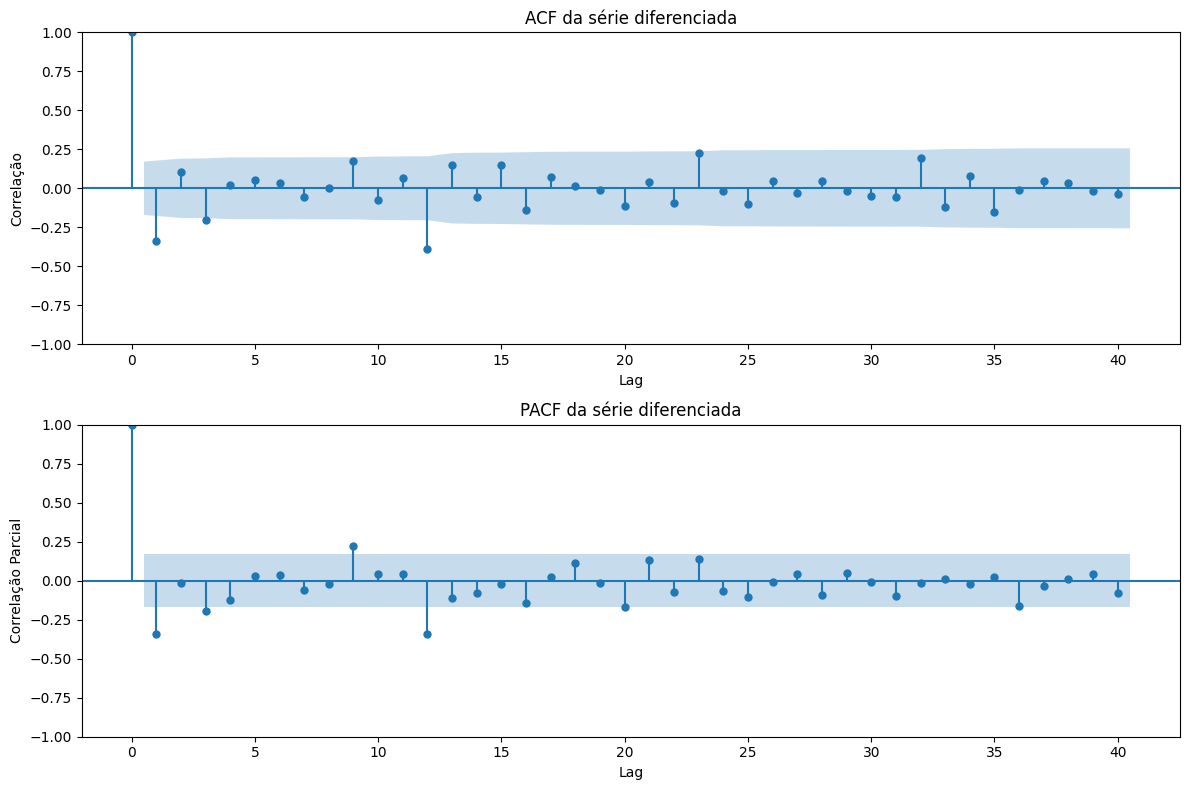

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
# ACF
plot_acf(diff_seasonal, lags=40, ax=axes[0], title='ACF da série diferenciada')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Correlação')

# PACF
plot_pacf(diff_seasonal, lags=40, ax=axes[1], title='PACF da série diferenciada', method='ywm')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Correlação Parcial')

plt.tight_layout()
plt.show()